# Notebook 07: Model Comparison Using Different Feature Sets

## Objective

The objective of this notebook is to compare the predictive performance of an XGBoost classifier using feature subsets obtained from different feature selection techniques.

The following feature sets are evaluated:

1. Random Forest Top 30 Features
2. Mutual Information Top 30 Features
3. XGBoost Top 30 Features
4. Chi-Square Top 30 Features
5. Consensus Features

For each feature set, the same machine learning pipeline is applied:

- Feature Selection
- Train-Test Split
- Borderline-SMOTE
- XGBoost Classification
- Performance Evaluation

The performance of all models is compared using multiple evaluation metrics to identify the most effective feature selection strategy for ADHD prediction.

---

## Workflow

Preprocessed Dataset

↓

Feature Selection Results

↓

Dataset Validation

↓

Model Training

↓

Performance Evaluation

↓

Model Comparison

↓

Best Model Selection

↓

SHAP Explainability

# SECTION 1: Import Required Libraries

This section imports all the Python libraries required for data manipulation, visualization, model training, class balancing, and model evaluation.

In [21]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split

# Borderline-SMOTE
from imblearn.over_sampling import BorderlineSMOTE

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display all dataframe columns
pd.set_option("display.max_columns", None)

print("All required libraries imported successfully.")

All required libraries imported successfully.


# SECTION 2: Load the Preprocessed Dataset

The preprocessed NSCH 2023–2024 dataset is loaded into memory.

The dataset has already undergone:

- Data cleaning
- Missing value treatment
- Removal of ADHD leakage variables
- Removal of administrative variables
- Creation of the target variable (`ADHD_binary`)

This dataset serves as the input for all subsequent machine learning experiments.

In [22]:
# ============================================================
# LOAD PREPROCESSED DATASET
# ============================================================

# Load the preprocessed NSCH dataset
df = pd.read_csv("../data/PROCESSED/NSCH_Preprocessed_ADHD.csv")

print("Dataset loaded successfully.\n")

print(f"Dataset Shape : {df.shape}")

print("\nFirst Five Rows:")

display(df.head())

Dataset loaded successfully.

Dataset Shape : (89228, 582)

First Five Rows:


,HEIGHT,FIPSST,STRATUM,HHID,FORMTYPE,TOTKIDS_R,TENURE,HHLANGUAGE,SC_AGE_YEARS,SC_SEX,BIRTH_MO,BIRTH_YR,K4Q30_R_1,K4Q30_R_2,K4Q30_R_3,DENTALSERV1,DENTALSERV2,DENTALSERV3,DENTALSERV4,DENTALSERV5,DENTALSERV6,DENTALSERV7,K11Q43R,A1_AGE,A2_AGE,HHCOUNT,FAMCOUNT,BREATHING,SWALLOWING,STOMACH,PHYSICALPAIN,TOOTHACHES,GUMBLEED,CAVITIES,MEMORYCOND,WALKSTAIRS,DRESSING,K2Q43B,BLINDNESS,ALLERGIES,K2Q40A,AUTOIMMUNE,K2Q61A,DIABETES,K2Q42A,HEART,HEADACHE,K2Q38A,K2Q33A,K2Q32A,DOWNSYN,BLOOD,CYSTFIB,FASD,K2Q34A,K2Q36A,K2Q60A,K2Q37A,K2Q30A,K2Q35A,K2Q31A,CONCUSSION,K2Q05,S4Q01,OVERWEIGHT,ENGAGE_FAST,ENGAGE_INTEREST,ENGAGE_PICKY,ENGAGE_BINGE,ENGAGE_PURG,ENGAGE_PILLS,ENGAGE_EXERCISE,ENGAGE_NOEAT,K4Q01,USUALGO,USUALSICK,VISIONSCREENOTHER,VISIONEXAMREC,EYEDOCTOR,K4Q23,K4Q27,HOSPITALSTAY,K6Q15,K4Q36,K5Q10,DECISIONS_R,K5Q21,CURRCOV,K12Q03,K12Q04,K12Q12,TRICARE,K11Q03R,HCCOVOTH,K3Q25,STOPWORK,CUTHOURS,AVOIDCHG,REPEATED,K7Q30,K7Q31,K7Q32,K7Q37,K7Q38,BORNUSA,K8Q35,K9Q40,VAPE,K11Q60,K11Q61,K11Q62,EBTCARDS,S9Q34,SSI,K10Q11,K10Q12,K10Q13,K10Q14,K10Q20,K10Q22,K10Q23,K9Q96,ACE3,ACE4,ACE5,ACE6,ACE7,ACE8,ACE9,ACE10,ACE11,VIDEOPHONE,BODYIMAGE,A1_SEX,A1_BORN,A1_EMPLOYED_R,A1_GRADE,A1_MARITAL,A1_RELATION,A2_SEX,A2_BORN,A2_EMPLOYED_R,A2_GRADE,A2_MARITAL,A2_RELATION,A1_ACTIVE,A2_ACTIVE,A1_PHYSHEALTH,A1_MENTHEALTH,A2_PHYSHEALTH,A2_MENTHEALTH,K2Q01,K2Q01_D,K5Q40,K5Q41,K5Q42,K5Q43,K5Q44,K3Q20,K3Q22,K3Q21B,K6Q71_R,K7Q84_R,K7Q85_R,K7Q82_R,K7Q83_R,K7Q70_R,BULLIED_R,BULLY,TALKABOUT,WKTOSOLVE,STRENGTHS,HOPEFUL,K10Q30,K10Q31,K10Q40_R,GOFORHELP,K10Q41_R,K8Q31,K8Q32,K8Q34,HOWMUCH,ATHOMEHC,ARRANGEHC,K7Q02R_R,K7Q04R_R,PHYSACTIV,HOURSLEEP,SCREENTIME,K8Q11,FOODSIT,EVALFASD,RECEVALFASD,MISSMORTGAGE,EVERHOMELESS,HCABILITY,K4Q20R,DOCROOM,WGTCONC,GOWHENSICK,DENTISTVISIT,K4Q22_R,K4Q24_R,C4Q04,HOSPITALER,K4Q04_R,K5Q20_R,K5Q30,K5Q31_R,K8Q21,K8Q30,K7Q33,BEDTIME,K3Q04_R,ACE1,MAKEFRIEND,SUGARDRINK,GRADES,HOMEEVIC,YEAR,CBSAFP_YN,METRO_YN,MPC_YN,TOTAGE_0_5,TOTAGE_6_11,TOTAGE_12_17,TOTCSHCN,TOTNONSHCN,SC_CSHCN,SC_RACE_R,SC_HISPANIC_R,SC_ENGLISH,SC_K2Q10,SC_K2Q13,SC_K2Q16,SC_K2Q19,SC_K2Q22,SC_AGE_LT4,SC_AGE_LT6,SC_AGE_LT9,SC_AGE_LT10,AGEPOS4,TENURE_IF,TOTMALE,TOTFEMALE,SC_RACE_R_IF,SC_RACER,SC_HISPANIC_R_IF,SC_SEX_IF,BIRTHWT_OZ_S,HOUSE_GEN,FAMILY_R,CURRINS,INSGAP,INSTYPE,BIRTHWT_VL,BIRTHWT_L,BIRTHWT,FPL_IF,A1_GRADE_IF,BIRTH_YR_F,SC_ASIAN,SC_AIAN,SC_NHPI,WEIGHT,BMICLASS,HHCOUNT_IF,HIGRADE,HIGRADE_TVIS,FPL_I1,FPL_I2,FPL_I3,FPL_I4,FPL_I5,FPL_I6,fwc_2324,hrsareg,age3_2324,age5_2324,sex_2324,race4_2324,raceAsia_2324,PrntNativity_2324,HHLanguage_2324,hisplang_2324,famstruct5_2324,povlev4_2324,povSCHIP_2324,AdultEduc_2324,MilitarySt_2324,FamCount_2324,BornUSA_2324,ChHlthSt_2324,TeethCond_2324,toothache_2324,gumbleed_2324,cavities_2324,OralProb_2324,BMI4_6to17_2324,BMI3_6to17_2324,ToldOverweight_2324,BodyImage_2324,PhysAct_2324,WgtConcn_2324,MealSkip_2324,LowInterest_2324,PickyEat_2324,binge_2324,purge_2324,DietPills_2324,OverExercise_2324,FearToEat_2324,LowBWght_2324,VeryLBWght_2324,BornPre_2324,CondCnt_2324,Cond2more_2324,allergies_2324,autoimmune_2324,asthma_2324,BloodScr_2324,blood_2324,palsy_2324,CystFibScr_2324,CystFib_2324,Type2diabetes_2324,DownSynd_2324,FASD_2324,seizure_2324,heart_2324,headache_2324,tourette_2324,anxiety_2324,depress_2324,behavior_2324,DevDelay_2324,IntDisab_2324,speech_2324,learning_2324,autism_2324,hearing_2324,vision_2324,BrainInjTold_2324,HeartBorn_2324,AllerSev_2324,AutoimmuneSev_2324,AsthmSev_2324,BloodSev_2324,PalsySev_2324,Type2DiabetSev_2324,SeizSev_2324,HeartSev_2324,HeadSev_2324,TouretSev_2324,AnxietSev_2324,DepresSev_2324,BehavSev_2324,DevDelSev_2324,IntDisSev_2324,SpeechSev_2324,LearnSev_2324,AutismSev_2324,Diff2more_2324,DiffBreath_2324,DiffSwall_2324,DiffDigest_2324,DiffPain_2324,DiffMem_2324,DiffWalk_2324,DiffDress_2324,CSHCN_2324,rxmeds_2324,serve_2324,func_2324,therapy_2324,mhealth_2324,qualnum4_2324,CSHCNtype_2324,CSHCNComplex_2324,mhneeds_2324,CSHCNExpanded_2324,CSHCNComplexExp_2324,DailyAct_2324,bully_2324,bullied_2324,flrsh6to17ct,flrish6to17_2324,curious6to

# SECTION 3: Load Feature Selection Results

The feature subsets generated from the feature selection phase are loaded.

The following feature sets will be evaluated independently:

- Random Forest
- Mutual Information
- XGBoost
- Chi-Square
- Consensus Features

In [23]:
# ============================================================
# LOAD FEATURE SELECTION RESULTS
# ============================================================

rf_features = pd.read_csv(
    "../data/FEATURE_SELECTION/Top30_RF_Features.csv"
)

mi_features = pd.read_csv(
    "../data/FEATURE_SELECTION/Top30_MI_Features.csv"
)

xgb_features = pd.read_csv(
    "../data/FEATURE_SELECTION/Top30_XGB_Features.csv"
)

chi_features = pd.read_csv(
    "../data/FEATURE_SELECTION/Top30_CHI_Features.csv"
)

consensus_features = pd.read_csv(
    "../data/FEATURE_SELECTION/Final_Consensus_Features.csv"
)

print("Feature lists loaded successfully.")

Feature lists loaded successfully.


In [24]:
# ============================================================
# EXTRACT FEATURE NAMES
# ============================================================

rf_features = rf_features["Feature"].tolist()

mi_features = mi_features["Feature"].tolist()

xgb_features = xgb_features["Feature"].tolist()

chi_features = chi_features["Feature"].tolist()

consensus_features = consensus_features["Feature"].tolist()

print(f"Random Forest Features      : {len(rf_features)}")
print(f"Mutual Information Features : {len(mi_features)}")
print(f"XGBoost Features            : {len(xgb_features)}")
print(f"Chi-Square Features         : {len(chi_features)}")
print(f"Consensus Features          : {len(consensus_features)}")

Random Forest Features      : 30
Mutual Information Features : 30
XGBoost Features            : 30
Chi-Square Features         : 30
Consensus Features          : 17


# ============================================================
# EXTRACT FEATURE NAMES
# ============================================================

rf_features = rf_features["Feature"].tolist()

mi_features = mi_features["Feature"].tolist()

xgb_features = xgb_features["Feature"].tolist()

chi_features = chi_features["Feature"].tolist()

consensus_features = consensus_features["Feature"].tolist()

print(f"Random Forest Features      : {len(rf_features)}")
print(f"Mutual Information Features : {len(mi_features)}")
print(f"XGBoost Features            : {len(xgb_features)}")
print(f"Chi-Square Features         : {len(chi_features)}")
print(f"Consensus Features          : {len(consensus_features)}")

## Dataset Information

The overall structure of the dataset is examined before proceeding with model development.

In [25]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nTarget Distribution")

print(df["ADHD_binary"].value_counts())

print("\nMissing Values")

print(df.isnull().sum().sum())

DATASET INFORMATION
Rows    : 89,228
Columns : 582

Target Distribution
ADHD_binary
0    77707
1    11521
Name: count, dtype: int64

Missing Values
0


## Non-Numeric Feature Validation

Machine learning algorithms such as Borderline-SMOTE and XGBoost require numerical input.

This validation step identifies any remaining non-numeric columns that may cause errors during model training.

In [26]:
# ============================================================
# CHECK NON-NUMERIC COLUMNS
# ============================================================

object_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("=" * 70)
print("NON-NUMERIC COLUMNS")
print("=" * 70)

if len(object_columns) == 0:

    print("No non-numeric columns found.")

else:

    print(f"Total Non-Numeric Columns : {len(object_columns)}")

    for column in object_columns:

        print(column)

NON-NUMERIC COLUMNS
Total Non-Numeric Columns : 2
BornUSA_2324
nomObesity6to17_2324


## Constant Feature Validation

Columns containing only a single unique value do not contribute useful information for classification.

Such columns are identified for removal prior to model training.

In [27]:
# ============================================================
# CHECK CONSTANT COLUMNS
# ============================================================

constant_columns = []

for column in df.columns:

    if df[column].nunique(dropna=False) == 1:

        constant_columns.append(column)

print("=" * 70)
print("CONSTANT COLUMNS")
print("=" * 70)

if len(constant_columns) == 0:

    print("No constant columns found.")

else:

    print(f"Total Constant Columns : {len(constant_columns)}")

    for column in constant_columns:

        print(column)

CONSTANT COLUMNS
Total Constant Columns : 5
SC_AGE_LT4
SC_AGE_LT6
SC_AGE_LT9
SC_AGE_LT10
BornUSA_2324


## Empty Column Validation

Columns containing only missing values are identified since they do not provide meaningful information for machine learning.

In [28]:
# ============================================================
# CHECK EMPTY COLUMNS
# ============================================================

empty_columns = []

for column in df.columns:

    if df[column].isna().all():

        empty_columns.append(column)

print("=" * 70)
print("EMPTY COLUMNS")
print("=" * 70)

if len(empty_columns) == 0:

    print("No empty columns found.")

else:

    print(f"Total Empty Columns : {len(empty_columns)}")

    for column in empty_columns:

        print(column)

EMPTY COLUMNS
No empty columns found.


## Feature List Validation

Each feature selection result is validated against the preprocessed dataset.

This ensures that every selected feature exists in the dataset before model training begins.

In [29]:
# ============================================================
# VALIDATE FEATURE LISTS
# ============================================================

feature_sets = {

    "Random Forest": rf_features,

    "Mutual Information": mi_features,

    "XGBoost": xgb_features,

    "Chi-Square": chi_features,

    "Consensus": consensus_features

}

print("=" * 70)
print("FEATURE VALIDATION")
print("=" * 70)

for name, features in feature_sets.items():

    missing = [

        feature

        for feature in features

        if feature not in df.columns

    ]

    if len(missing) == 0:

        print(f"{name:<22} : PASS")

    else:

        print(f"{name:<22} : FAIL")

        print(missing)

FEATURE VALIDATION
Random Forest          : PASS
Mutual Information     : PASS
XGBoost                : PASS
Chi-Square             : PASS
Consensus              : PASS


## Validation Summary

A summary of all validation checks is presented before proceeding to model development.

In [30]:
# ============================================================
# VALIDATION SUMMARY
# ============================================================

print("=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print(f"Dataset Shape            : {df.shape}")

print(f"Non-Numeric Columns      : {len(object_columns)}")

print(f"Constant Columns         : {len(constant_columns)}")

print(f"Completely Empty Columns : {len(empty_columns)}")

print("\nDataset validation completed successfully.")

VALIDATION SUMMARY
Dataset Shape            : (89228, 582)
Non-Numeric Columns      : 2
Constant Columns         : 5
Completely Empty Columns : 0

Dataset validation completed successfully.


# SECTION 4.1: Dataset Cleaning

Based on the validation results, the dataset is cleaned before model training.

The following operations are performed:

1. Remove constant columns
2. Convert numeric string columns to numeric data types
3. Verify that all remaining columns are suitable for machine learning

This ensures that the dataset is fully compatible with Borderline-SMOTE and XGBoost.

In [31]:
# ============================================================
# REMOVE CONSTANT COLUMNS
# ============================================================

if len(constant_columns) > 0:

    print("Removing constant columns...")

    df = df.drop(columns=constant_columns)

    print(f"Removed {len(constant_columns)} constant columns.")

else:

    print("No constant columns to remove.")

print("\nUpdated Dataset Shape:")
print(df.shape)

Removing constant columns...
Removed 5 constant columns.

Updated Dataset Shape:
(89228, 577)


In [34]:
# ============================================================
# CONVERT NUMERIC STRING COLUMNS
# ============================================================

print("=" * 70)
print("CONVERTING NUMERIC STRING COLUMNS")
print("=" * 70)

object_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

if len(object_columns) == 0:

    print("No non-numeric columns found.")

else:

    for column in object_columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

        print(f"Converted : {column}")

CONVERTING NUMERIC STRING COLUMNS
Converted : nomObesity6to17_2324


In [35]:
# ============================================================
# FINAL DATA VALIDATION
# ============================================================

remaining_objects = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

if len(remaining_objects) == 0:

    print("Dataset is fully numeric.")
    print("Ready for model training.")

else:

    print("Remaining non-numeric columns:")

    for column in remaining_objects:

        print(column)

FINAL VALIDATION
Dataset is fully numeric.
Ready for model training.


# SECTION 4.2: Save Model-Ready Dataset

After validation and cleaning, the final model-ready dataset is saved.

This dataset will be used in subsequent notebooks, including:

- Model Comparison
- SHAP Explainability
- Hyperparameter Tuning

Saving the cleaned dataset ensures consistency and reproducibility across all experiments.

In [36]:
# ============================================================
# SAVE MODEL-READY DATASET
# ============================================================

df.to_csv(
    "../data/PROCESSED/NSCH_Preprocessed_ADHD_ModelReady.csv",
    index=False
)

print("Model-ready dataset saved successfully.")

print(f"Dataset Shape: {df.shape}")

Model-ready dataset saved successfully.
Dataset Shape: (89228, 577)


# SECTION 5: Define Model Evaluation Function

To ensure a fair and consistent comparison, a reusable evaluation function is defined.

The function performs the complete machine learning pipeline for each feature set.

The pipeline consists of the following steps:

1. Validate feature availability
2. Validate feature data types
3. Select features and target variable
4. Split the dataset into training and testing sets
5. Balance the training data using Borderline-SMOTE
6. Train an XGBoost classifier
7. Generate predictions
8. Evaluate model performance
9. Return the trained model and evaluation results

Using a common evaluation function guarantees that every feature set is assessed under identical experimental conditions.

In [37]:
# ============================================================
# DEFINE MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_feature_set(feature_list, feature_set_name):

    """
    Train and evaluate an XGBoost classifier using a given feature set.

    Parameters
    ----------
    feature_list : list
        List of selected feature names.

    feature_set_name : str
        Name of the feature selection method.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics,
        trained model and prediction results.
    """

    print("=" * 70)
    print(f"Evaluating Feature Set : {feature_set_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Validate Feature Availability
    # --------------------------------------------------------

    missing_features = [

        feature

        for feature in feature_list

        if feature not in df.columns

    ]

    if len(missing_features) > 0:

        raise ValueError(

            f"The following features are missing:\n{missing_features}"

        )

    # --------------------------------------------------------
    # Select Features and Target
    # --------------------------------------------------------

    X = df[feature_list].copy()

    y = df["ADHD_binary"]

    print(f"Number of Features : {X.shape[1]}")
    print(f"Dataset Shape      : {X.shape}")

    # --------------------------------------------------------
    # Validate Feature Data Types
    # --------------------------------------------------------

    non_numeric_columns = X.select_dtypes(

        include=["object", "string"]

    ).columns.tolist()

    if len(non_numeric_columns) > 0:

        raise ValueError(

            f"Non-numeric columns detected:\n{non_numeric_columns}"

        )

    # --------------------------------------------------------
    # Train-Test Split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y

    )

    # --------------------------------------------------------
    # Apply Borderline-SMOTE
    # --------------------------------------------------------

    smote = BorderlineSMOTE(

        random_state=42

    )

    X_train_resampled, y_train_resampled = smote.fit_resample(

        X_train,

        y_train

    )

    print("\nClass Distribution After Borderline-SMOTE")

    print(y_train_resampled.value_counts())

    # --------------------------------------------------------
    # Train XGBoost Classifier
    # --------------------------------------------------------

    model = XGBClassifier(

        n_estimators=200,

        max_depth=6,

        learning_rate=0.1,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        eval_metric="logloss"

    )

    model.fit(

        X_train_resampled,

        y_train_resampled

    )

    # --------------------------------------------------------
    # Generate Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Calculate Evaluation Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(

        y_test,

        y_pred

    )

    precision = precision_score(

        y_test,

        y_pred

    )

    recall = recall_score(

        y_test,

        y_pred

    )

    f1 = f1_score(

        y_test,

        y_pred

    )

    roc_auc = roc_auc_score(

        y_test,

        y_prob

    )

    # --------------------------------------------------------
    # Display Results
    # --------------------------------------------------------

    print("\nAccuracy :", round(accuracy, 4))

    print("Precision:", round(precision, 4))

    print("Recall   :", round(recall, 4))

    print("F1 Score :", round(f1, 4))

    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    # --------------------------------------------------------
    # Return Results
    # --------------------------------------------------------

    return {

        "Feature_Set": feature_set_name,

        "No_of_Features": X.shape[1],

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1_Score": f1,

        "ROC_AUC": roc_auc,

        "Model": model,

        "X_test": X_test,

        "y_test": y_test,

        "y_pred": y_pred,

        "y_prob": y_prob,

        "Confusion_Matrix": confusion_matrix(
            y_test,
            y_pred
        ),

        "Classification_Report": classification_report(
            y_test,
            y_pred,
            output_dict=True
        )

    }

# SECTION 6: Train and Evaluate Models

Each feature subset is evaluated independently using the same machine learning pipeline.

For every feature set, the following steps are performed:

1. Feature validation
2. Train-test split
3. Borderline-SMOTE
4. XGBoost model training
5. Performance evaluation

Using an identical evaluation pipeline ensures that differences in performance are solely due to the selected features rather than variations in model training.

In [38]:
# ============================================================
# TRAIN AND EVALUATE ALL FEATURE SETS
# ============================================================

results = []

# ------------------------------------------------------------
# Random Forest Feature Set
# ------------------------------------------------------------

rf_results = evaluate_feature_set(
    rf_features,
    "Random Forest"
)

results.append(rf_results)

# ------------------------------------------------------------
# Mutual Information Feature Set
# ------------------------------------------------------------

mi_results = evaluate_feature_set(
    mi_features,
    "Mutual Information"
)

results.append(mi_results)

# ------------------------------------------------------------
# XGBoost Feature Set
# ------------------------------------------------------------

xgb_results = evaluate_feature_set(
    xgb_features,
    "XGBoost"
)

results.append(xgb_results)

# ------------------------------------------------------------
# Chi-Square Feature Set
# ------------------------------------------------------------

chi_results = evaluate_feature_set(
    chi_features,
    "Chi-Square"
)

results.append(chi_results)

# ------------------------------------------------------------
# Consensus Feature Set
# ------------------------------------------------------------

consensus_results = evaluate_feature_set(
    consensus_features,
    "Consensus"
)

results.append(consensus_results)

print("\nAll feature sets have been evaluated successfully.")

Evaluating Feature Set : Random Forest
Number of Features : 30
Dataset Shape      : (89228, 30)

Class Distribution After Borderline-SMOTE
ADHD_binary
0    62165
1    62165
Name: count, dtype: int64

Accuracy : 0.9324
Precision: 0.6797
Recall   : 0.9006
F1 Score : 0.7747
ROC-AUC  : 0.9771

Confusion Matrix
[[14564   978]
 [  229  2075]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     15542
           1       0.68      0.90      0.77      2304

    accuracy                           0.93     17846
   macro avg       0.83      0.92      0.87     17846
weighted avg       0.95      0.93      0.94     17846

Evaluating Feature Set : Mutual Information
Number of Features : 30
Dataset Shape      : (89228, 30)

Class Distribution After Borderline-SMOTE
ADHD_binary
0    62165
1    62165
Name: count, dtype: int64

Accuracy : 0.9024
Precision: 0.5794
Recall   : 0.8915
F1 Score : 0.7023
ROC-AUC  : 0.9656

Confusion Matri

ValueError: Input X contains NaN.
BorderlineSMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [39]:
# ============================================================
# CHECK MISSING VALUES IN CHI-SQUARE FEATURES
# ============================================================

X_chi = df[chi_features]

missing = X_chi.isnull().sum()
missing = missing[missing > 0]

print(missing)

nomObesity6to17_2324    3021
dtype: int64


In [44]:
# ============================================================
# IMPUTE MISSING VALUES
# ============================================================

mode_value = df["nomObesity6to17_2324"].mode().iloc[0]

print("Mode:", mode_value)
print("Missing Before:", df["nomObesity6to17_2324"].isna().sum())

df["nomObesity6to17_2324"] = (
    df["nomObesity6to17_2324"]
    .fillna(mode_value)
)

print("Missing After:", df["nomObesity6to17_2324"].isna().sum())

Mode: 2.0
Missing Before: 3021
Missing After: 0


In [41]:
print(df["nomObesity6to17_2324"].dtype)

print(df["nomObesity6to17_2324"].head())

print(df["nomObesity6to17_2324"].mode())

print(df["nomObesity6to17_2324"].isna().sum())

float64
0     2.0
1     2.0
2    90.0
3    90.0
4     2.0
Name: nomObesity6to17_2324, dtype: float64
0    2.0
Name: nomObesity6to17_2324, dtype: float64
3021


In [42]:
# Number of missing values
print(df["nomObesity6to17_2324"].isna().sum())

# Show the actual missing rows
print(df[df["nomObesity6to17_2324"].isna()].head())

3021
     HEIGHT  FIPSST  STRATUM      HHID  FORMTYPE  TOTKIDS_R  TENURE  \
58   162.56      23        1  23000554         2          1       1   
84   162.56      48        1  23000840         2          2       3   
139  162.56      20        1  23001323         2          4       3   
226  162.56      18        1  23001917         3          2       1   
235  162.56      27        1  23002063         2          1       1   

     HHLANGUAGE  SC_AGE_YEARS  SC_SEX  BIRTH_MO  BIRTH_YR  K4Q30_R_1  \
58          1.0             6       1       8.0    2007.0        1.0   
84          2.0            10       2       2.0    2013.0        1.0   
139         1.0            11       2      10.0    2011.0        1.0   
226         1.0            13       2       8.0    2017.0        1.0   
235         1.0             9       1      11.0    2013.0        1.0   

     K4Q30_R_2  K4Q30_R_3  DENTALSERV1  DENTALSERV2  DENTALSERV3  DENTALSERV4  \
58         2.0        2.0          1.0          1.0   

In [43]:
print(df["nomObesity6to17_2324"].value_counts(dropna=False))

nomObesity6to17_2324
2.0     57342
90.0    19393
1.0      9472
NaN      3021
Name: count, dtype: int64


In [45]:
# ============================================================
# VERIFY NO MISSING VALUES IN CHI-SQUARE FEATURES
# ============================================================

X_chi = df[chi_features]

missing = X_chi.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [47]:
results = []

print("Starting RF...")
rf_results = evaluate_feature_set(rf_features, "Random Forest")
results.append(rf_results)
print("RF Done\n")

print("Starting MI...")
mi_results = evaluate_feature_set(mi_features, "Mutual Information")
results.append(mi_results)
print("MI Done\n")

print("Starting XGB...")
xgb_results = evaluate_feature_set(xgb_features, "XGBoost")
results.append(xgb_results)
print("XGB Done\n")

print("Starting CHI...")
chi_results = evaluate_feature_set(chi_features, "Chi-Square")
results.append(chi_results)
print("CHI Done\n")

print("Starting Consensus...")
consensus_results = evaluate_feature_set(consensus_features, "Consensus")
results.append(consensus_results)
print("Consensus Done\n")

print("ALL MODELS COMPLETED!")

Starting RF...
Evaluating Feature Set : Random Forest
Number of Features : 30
Dataset Shape      : (89228, 30)

Class Distribution After Borderline-SMOTE
ADHD_binary
0    62165
1    62165
Name: count, dtype: int64

Accuracy : 0.9324
Precision: 0.6797
Recall   : 0.9006
F1 Score : 0.7747
ROC-AUC  : 0.9771

Confusion Matrix
[[14564   978]
 [  229  2075]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     15542
           1       0.68      0.90      0.77      2304

    accuracy                           0.93     17846
   macro avg       0.83      0.92      0.87     17846
weighted avg       0.95      0.93      0.94     17846

RF Done

Starting MI...
Evaluating Feature Set : Mutual Information
Number of Features : 30
Dataset Shape      : (89228, 30)

Class Distribution After Borderline-SMOTE
ADHD_binary
0    62165
1    62165
Name: count, dtype: int64

Accuracy : 0.9024
Precision: 0.5794
Recall   : 0.8915
F1 Score : 0.

# SECTION 7: Model Performance Comparison

The performance of the five feature selection methods is compared using the
same XGBoost classifier and Borderline-SMOTE preprocessing.

The evaluation metrics include:

- Number of Features
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

This comparison helps identify the best feature subset for the final ADHD prediction model.

In [48]:
# ============================================================
# CREATE MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Feature Selection": [
        rf_results["Feature_Set"],
        mi_results["Feature_Set"],
        xgb_results["Feature_Set"],
        chi_results["Feature_Set"],
        consensus_results["Feature_Set"]
    ],

    "No. of Features": [
        rf_results["No_of_Features"],
        mi_results["No_of_Features"],
        xgb_results["No_of_Features"],
        chi_results["No_of_Features"],
        consensus_results["No_of_Features"]
    ],

    "Accuracy": [
        rf_results["Accuracy"],
        mi_results["Accuracy"],
        xgb_results["Accuracy"],
        chi_results["Accuracy"],
        consensus_results["Accuracy"]
    ],

    "Precision": [
        rf_results["Precision"],
        mi_results["Precision"],
        xgb_results["Precision"],
        chi_results["Precision"],
        consensus_results["Precision"]
    ],

    "Recall": [
        rf_results["Recall"],
        mi_results["Recall"],
        xgb_results["Recall"],
        chi_results["Recall"],
        consensus_results["Recall"]
    ],

    "F1-Score": [
        rf_results["F1_Score"],
        mi_results["F1_Score"],
        xgb_results["F1_Score"],
        chi_results["F1_Score"],
        consensus_results["F1_Score"]
    ],

    "ROC-AUC": [
        rf_results["ROC_AUC"],
        mi_results["ROC_AUC"],
        xgb_results["ROC_AUC"],
        chi_results["ROC_AUC"],
        consensus_results["ROC_AUC"]
    ]

})

comparison_df = comparison_df.round(4)

comparison_df

,Feature Selection,No. of Features,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,30,0.9324,0.6797,0.9006,0.7747,0.9771
1,Mutual Information,30,0.9024,0.5794,0.8915,0.7023,0.9656
2,XGBoost,30,0.9537,0.7677,0.9193,0.8367,0.9876
3,Chi-Square,30,0.9175,0.7028,0.6250,0.6616,0.9501
4,Consensus,17,0.8756,0.5096,0.9679,0.6677,0.9533


In [49]:
# ============================================================
# SAVE MODEL COMPARISON RESULTS
# ============================================================

comparison_df.to_csv(
    "../data/FEATURE_SELECTION/Model_Comparison_Results.csv",
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


# SECTION 8: Confusion Matrix Comparison

The confusion matrix summarizes the classification performance of each feature selection method.

Each matrix shows:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

This enables a detailed comparison of prediction errors across all feature selection techniques.

In [50]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

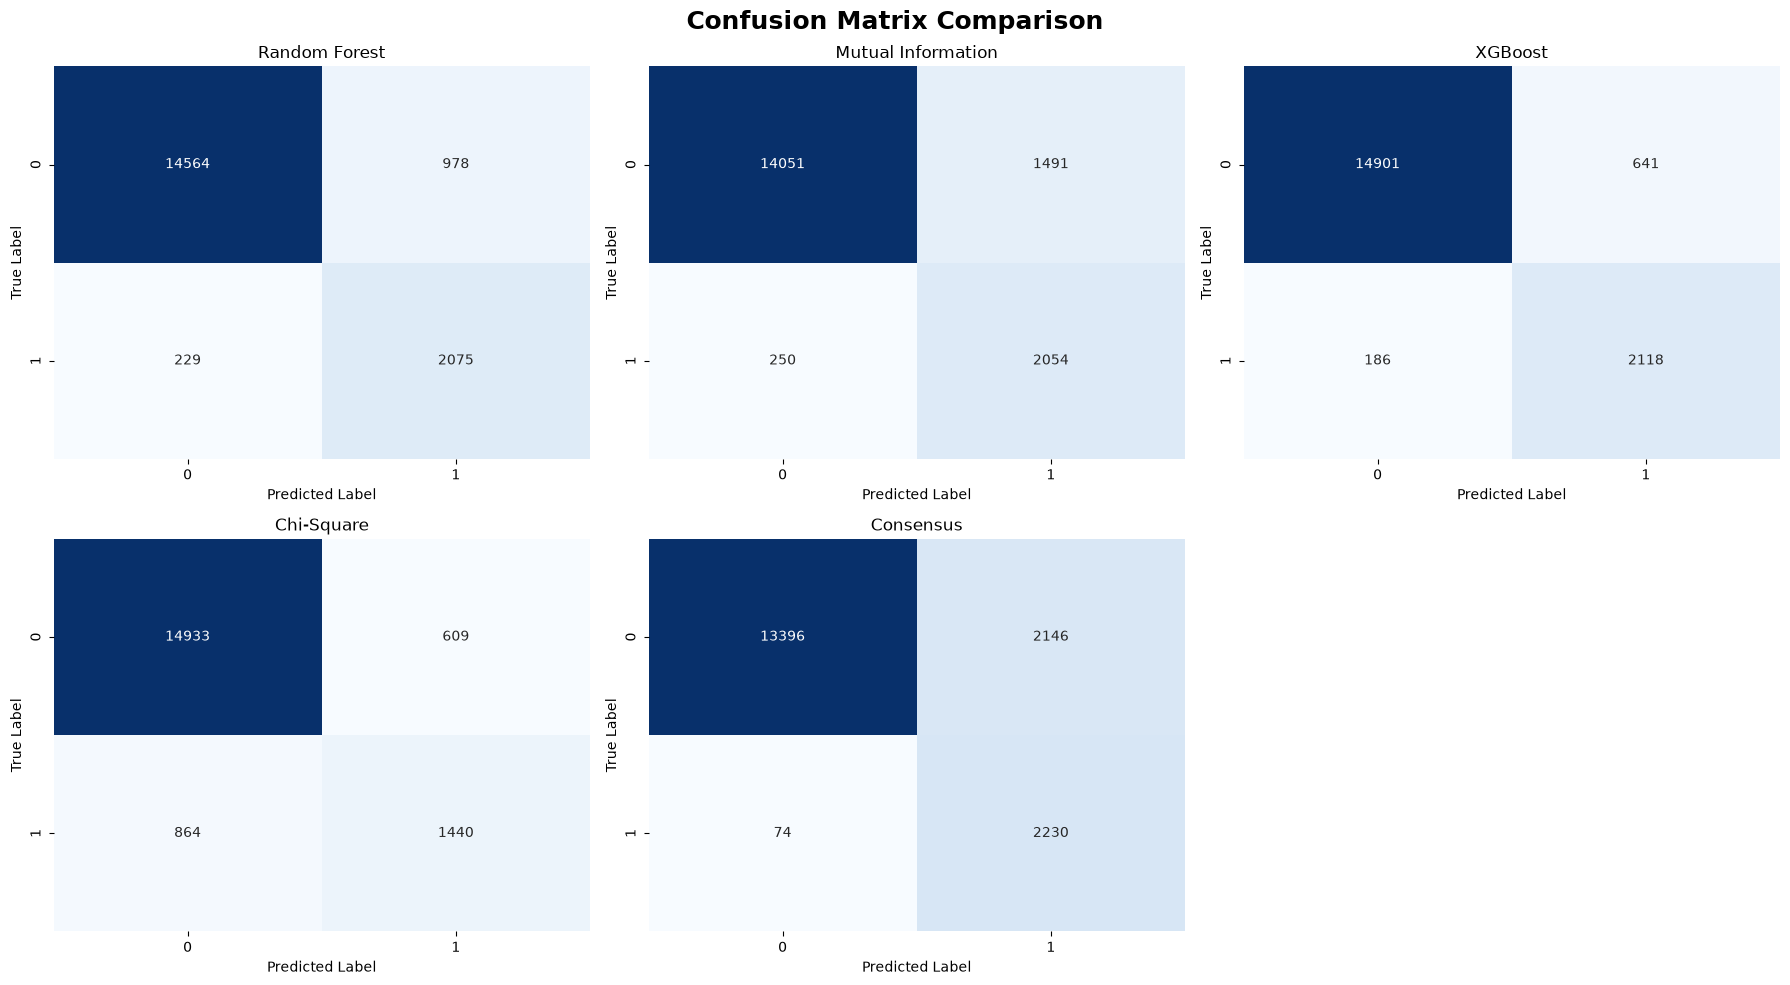

In [51]:
# ============================================================
# PLOT CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.ravel()

model_results = [
    rf_results,
    mi_results,
    xgb_results,
    chi_results,
    consensus_results
]

titles = [
    "Random Forest",
    "Mutual Information",
    "XGBoost",
    "Chi-Square",
    "Consensus"
]

for i, (result, title) in enumerate(zip(model_results, titles)):

    sns.heatmap(

        result["Confusion_Matrix"],

        annot=True,

        fmt="d",

        cmap="Blues",

        cbar=False,

        ax=axes[i]

    )

    axes[i].set_title(title, fontsize=12)

    axes[i].set_xlabel("Predicted Label")

    axes[i].set_ylabel("True Label")

# Remove last empty subplot
fig.delaxes(axes[5])

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [52]:
# ============================================================
# SAVE CONFUSION MATRIX FIGURE
# ============================================================

fig.savefig(
    "../data/FEATURE_SELECTION/Confusion_Matrix_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Confusion matrix comparison saved successfully.")

Confusion matrix comparison saved successfully.


# SECTION 9: Performance Comparison Visualization

This section visualizes the performance of all feature selection methods
using five evaluation metrics.

The following metrics are compared:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These visualizations provide an intuitive comparison of the predictive
performance obtained using different feature selection techniques.

In [53]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt

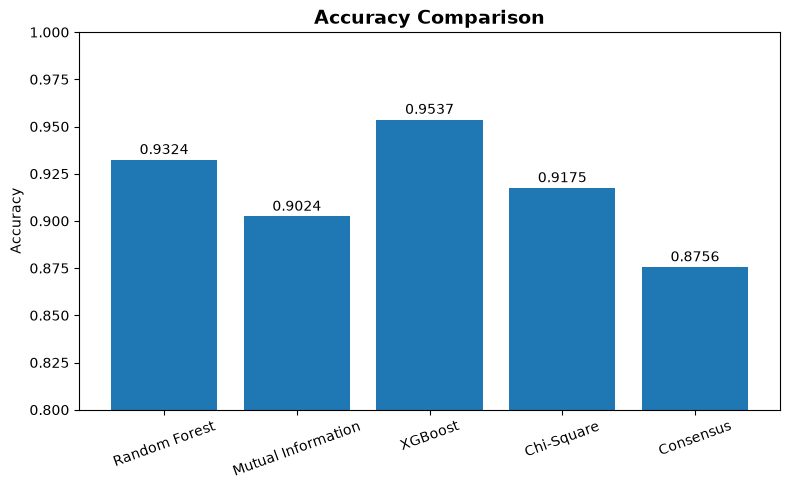

In [54]:
# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Feature Selection"],
    comparison_df["Accuracy"]
)

plt.title(
    "Accuracy Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Accuracy")
plt.ylim(0.80, 1.00)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height() + 0.003,

        f"{bar.get_height():.4f}",

        ha="center",

        fontsize=10

    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/Accuracy_Comparison.png",
    dpi=300
)

plt.show()

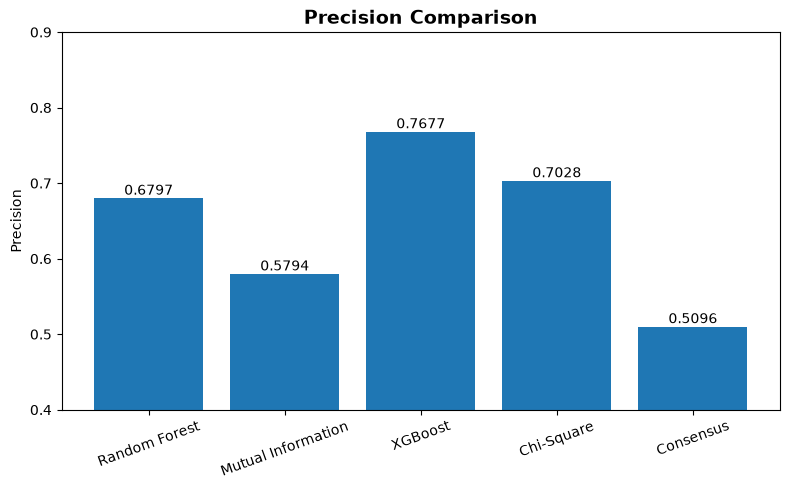

In [55]:
# ============================================================
# PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Feature Selection"],
    comparison_df["Precision"]
)

plt.title(
    "Precision Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Precision")
plt.ylim(0.40, 0.90)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.005,

        f"{bar.get_height():.4f}",

        ha="center"

    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/Precision_Comparison.png",
    dpi=300
)

plt.show()

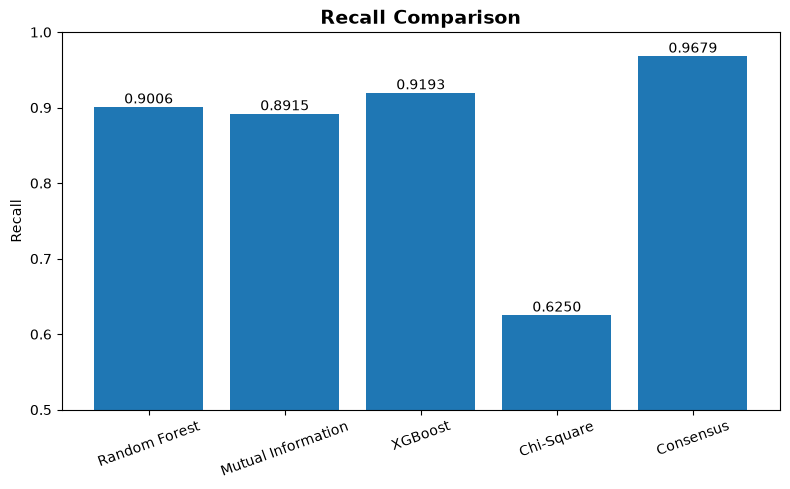

In [56]:
# ============================================================
# RECALL COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Feature Selection"],
    comparison_df["Recall"]
)

plt.title(
    "Recall Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Recall")
plt.ylim(0.50, 1.00)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.005,

        f"{bar.get_height():.4f}",

        ha="center"

    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/Recall_Comparison.png",
    dpi=300
)

plt.show()

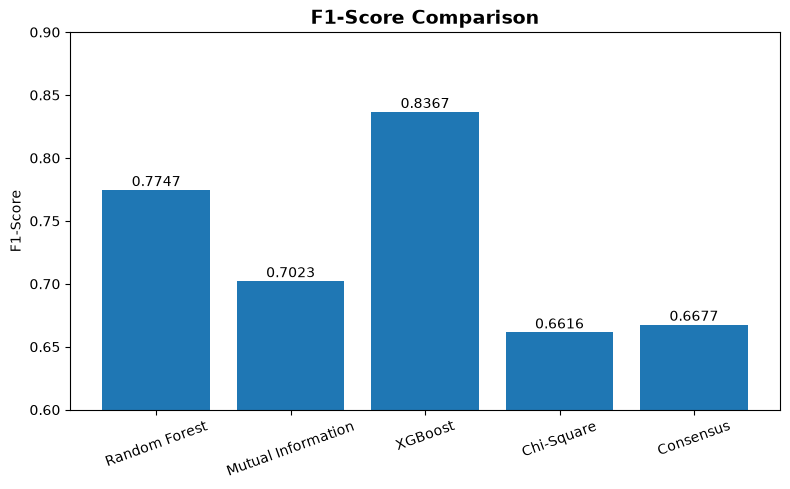

In [57]:
# ============================================================
# F1-SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Feature Selection"],
    comparison_df["F1-Score"]
)

plt.title(
    "F1-Score Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("F1-Score")
plt.ylim(0.60, 0.90)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.003,

        f"{bar.get_height():.4f}",

        ha="center"

    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/F1_Comparison.png",
    dpi=300
)

plt.show()

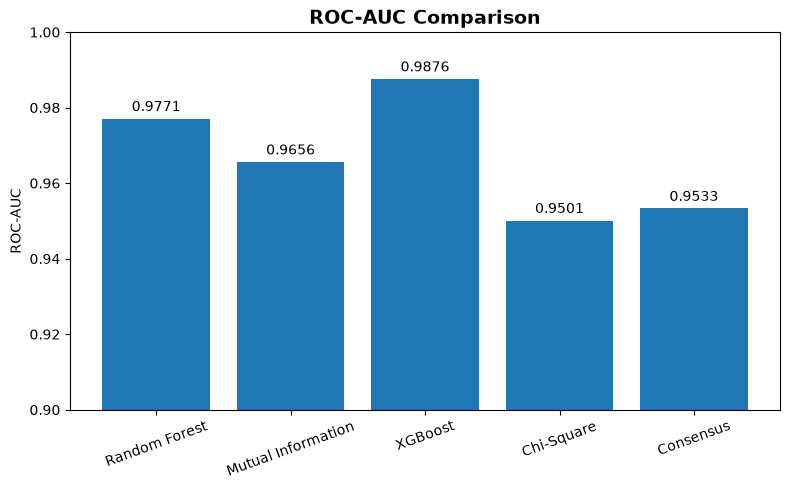

In [58]:
# ============================================================
# ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Feature Selection"],
    comparison_df["ROC-AUC"]
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("ROC-AUC")
plt.ylim(0.90, 1.00)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.002,

        f"{bar.get_height():.4f}",

        ha="center"

    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/ROC_AUC_Comparison.png",
    dpi=300
)

plt.show()

# SECTION 10: Best Feature Selection Method

This section identifies the best-performing feature selection method based
on the evaluation results obtained from the XGBoost classifier.

The method with the highest ROC-AUC score is selected as the final feature
selection technique for the explainable ADHD prediction model.

The selected feature set will be used in the next notebook for SHAP-based
model interpretation and explainability analysis.

In [59]:
# ============================================================
# IDENTIFY BEST FEATURE SELECTION METHOD
# ============================================================

best_model = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

print("=" * 70)
print("BEST FEATURE SELECTION METHOD")
print("=" * 70)

print(f"Feature Selection : {best_model['Feature Selection']}")
print(f"No. of Features   : {best_model['No. of Features']}")
print(f"Accuracy          : {best_model['Accuracy']:.4f}")
print(f"Precision         : {best_model['Precision']:.4f}")
print(f"Recall            : {best_model['Recall']:.4f}")
print(f"F1-Score          : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC           : {best_model['ROC-AUC']:.4f}")

BEST FEATURE SELECTION METHOD
Feature Selection : XGBoost
No. of Features   : 30
Accuracy          : 0.9537
Precision         : 0.7677
Recall            : 0.9193
F1-Score          : 0.8367
ROC-AUC           : 0.9876


In [60]:
# ============================================================
# SAVE BEST MODEL SUMMARY
# ============================================================

best_model.to_frame().T.to_csv(
    "../data/FEATURE_SELECTION/Best_Model_Results.csv",
    index=False
)

print("Best model summary saved successfully.")

Best model summary saved successfully.


In [61]:
# ============================================================
# STORE BEST FEATURE LIST
# ============================================================

if best_model["Feature Selection"] == "Random Forest":
    best_features = rf_features

elif best_model["Feature Selection"] == "Mutual Information":
    best_features = mi_features

elif best_model["Feature Selection"] == "XGBoost":
    best_features = xgb_features

elif best_model["Feature Selection"] == "Chi-Square":
    best_features = chi_features

else:
    best_features = consensus_features

print("=" * 70)
print("BEST FEATURE LIST LOADED")
print("=" * 70)

print(f"Number of Features : {len(best_features)}")

print("\nSelected Features:")

for feature in best_features:
    print(feature)

BEST FEATURE LIST LOADED
Number of Features : 30

Selected Features:
MEDB10ScrQ5_2324
MedEmotion_2324
K2Q33A
MEMORYCOND
SchlEngage_2324
CSHCNComplex_2324
K2Q32A
K7Q84_R
K7Q83_R
CSHCNExpanded_2324
speech_2324
SC_SEX
SC_ENGLISH
SC_K2Q19
Diff2more_2324
DepresSev_2324
anxiety_2324
mhealth_2324
SC_K2Q22
depress_2324
DevDelay_2324
learning_2324
CondCnt_2324
AnxietSev_2324
SpeechSev_2324
behavior_2324
K2Q34A
SC_K2Q10
SC_CSHCN
DevDelSev_2324


In [62]:
# ============================================================
# SAVE FINAL FEATURE LIST
# ============================================================

pd.DataFrame({
    "Feature": best_features
}).to_csv(
    "../data/FEATURE_SELECTION/Final_Selected_Features.csv",
    index=False
)

print("Final selected feature list saved successfully.")

Final selected feature list saved successfully.


# SECTION 11: Conclusion

This notebook evaluated five different feature selection methods for ADHD prediction using the NSCH 2023–2024 dataset.

The evaluated feature selection methods were:

- Random Forest
- Mutual Information
- XGBoost
- Chi-Square
- Consensus Feature Selection

Each feature subset was evaluated using the same machine learning pipeline consisting of:

- Train-test split
- Borderline-SMOTE
- XGBoost classifier
- Performance evaluation

The best-performing feature selection method was automatically identified based on the highest ROC-AUC score.

The selected feature subset will be used in the next notebook to train the final XGBoost model and perform SHAP-based explainability analysis.

In [63]:
# ============================================================
# NOTEBOOK COMPLETED
# ============================================================

print("=" * 70)
print("FEATURE SELECTION NOTEBOOK COMPLETED")
print("=" * 70)

print(f"Dataset Shape          : {df.shape}")
print(f"Target Variable        : ADHD_binary")
print(f"Best Feature Selection : {best_model['Feature Selection']}")
print(f"Number of Features     : {len(best_features)}")
print(f"Best ROC-AUC           : {best_model['ROC-AUC']:.4f}")

print("\nNext Notebook:")
print("08_SHAP_Explainability.ipynb")

print("=" * 70)

FEATURE SELECTION NOTEBOOK COMPLETED
Dataset Shape          : (89228, 577)
Target Variable        : ADHD_binary
Best Feature Selection : XGBoost
Number of Features     : 30
Best ROC-AUC           : 0.9876

Next Notebook:
08_SHAP_Explainability.ipynb
